In [3]:
import torch
import torchvision.transforms as T
import torchvision.models.segmentation as models
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score, f1_score, accuracy_score, precision_score

In [4]:
#Carrega 5 images from Oxford-IIIT Pet
ds = tfds.load('oxford_iiit_pet:4.*.*', split='test[:5]', as_supervised=False)
ds = list(tfds.as_numpy(ds))

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Transformacao para o DeepLabV3+ (224x224, normalized)
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Pré-processamento das imagens
image_tensors = []
original_images = []
true_masks = []

for example in ds:
    img_np = example["image"]
    mask_np = example["segmentation_mask"]

    # Store original for visualization
    original_images.append(img_np)

    # Preprocess image
    img = Image.fromarray(img_np)
    img_tensor = transform(img)
    image_tensors.append(img_tensor)

    # Resize and simplify mask: pet = 1, fundo = 0
    mask = Image.fromarray(mask_np.squeeze().astype(np.uint8)).resize((224, 224), resample=Image.NEAREST)
    mask_arr = np.array(mask)
    mask_binary = np.where(mask_arr > 0, 1, 0)
    true_masks.append(mask_binary)

# Empilha imagens
input_batch = torch.stack(image_tensors).to(device)

In [6]:
# Modelo DeepLabV3+ pré-treinado (COCO)
model = models.deeplabv3_resnet101(pretrained=True).eval().to(device)

#Predição
with torch.no_grad():
    outputs = model(input_batch)['out']  # [B, C, H, W]
    preds = torch.argmax(outputs, dim=1).cpu().numpy()  # [B, H, W]

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# Classes de "pet" no COCO
PET_CLASSES = [8, 12]
pred_masks_binary = np.isin(preds, PET_CLASSES).astype(np.uint8)  # pet=1, fundo=0

In [8]:
# Avaliação
ious, dices, accs, precisions = [], [], [], []

 MÉTRICAS MÉDIAS NAS 5 IMAGENS:
 Intersection over Union: 0.2911
 Dice Coefficient:  0.4349
 Pixel Accuracy:    0.2911
 Precision:         1.0000


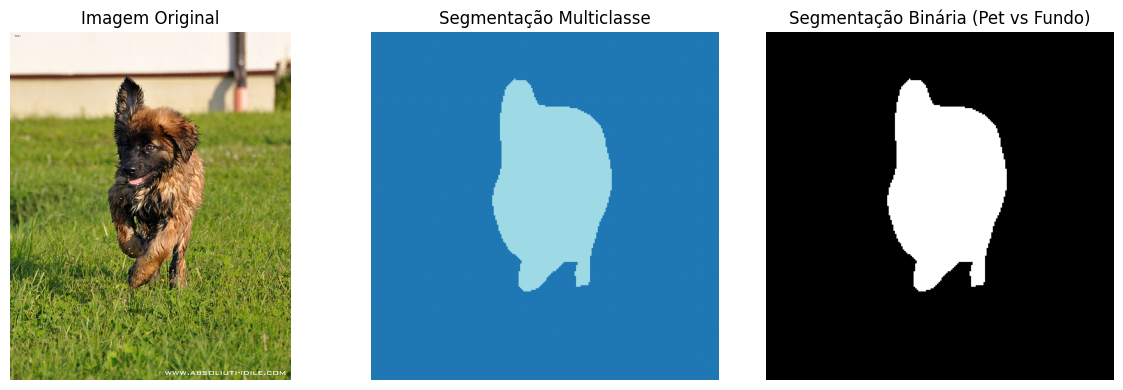

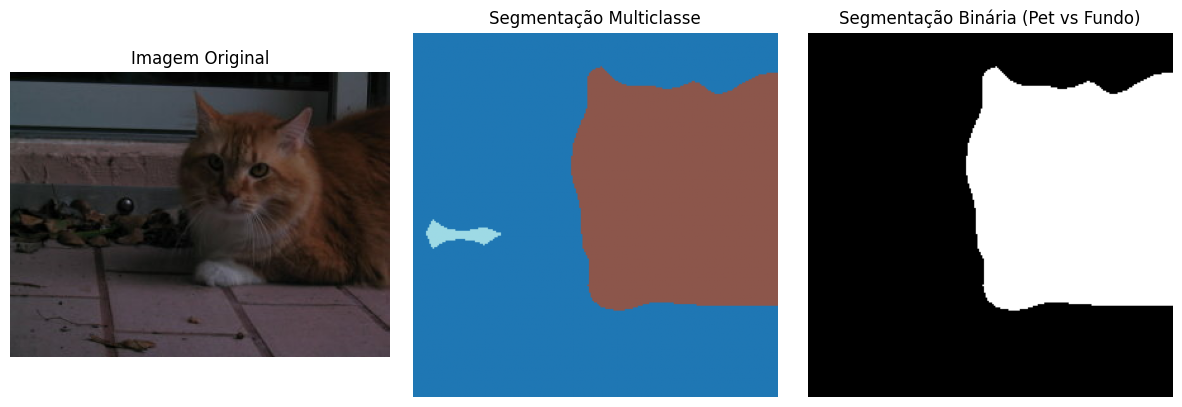

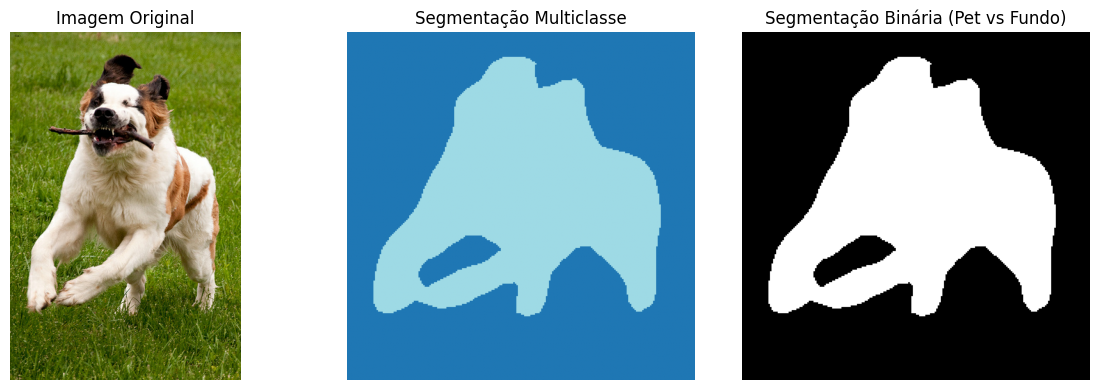

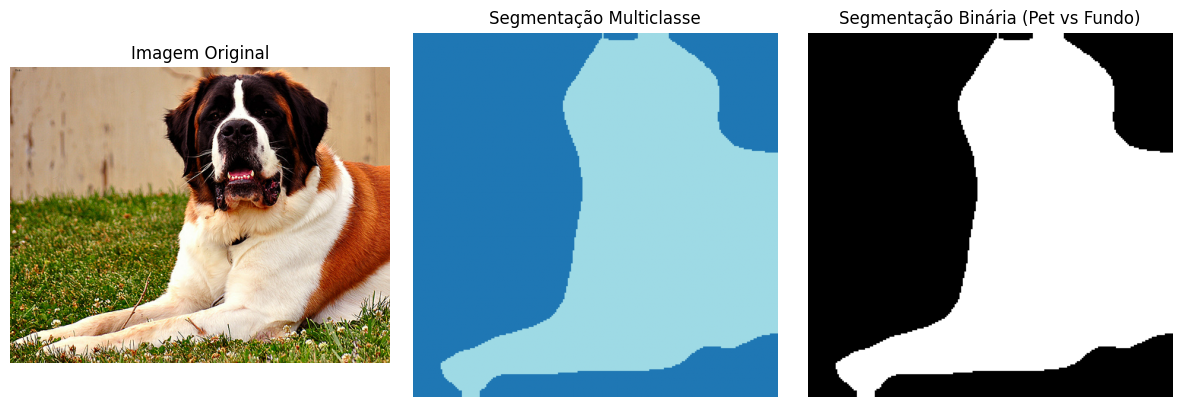

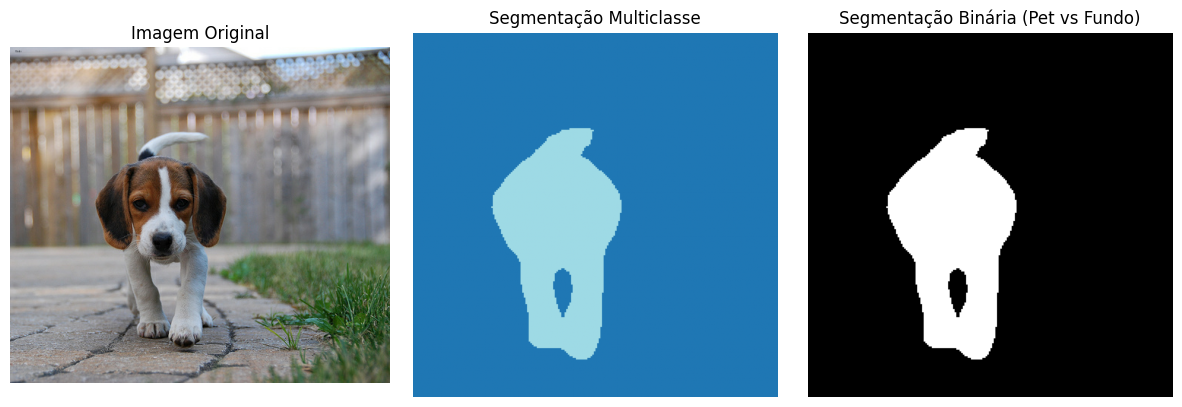

In [9]:
for y_true, y_pred in zip(true_masks, pred_masks_binary):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    ious.append(jaccard_score(y_true_flat, y_pred_flat))
    dices.append(f1_score(y_true_flat, y_pred_flat))
    accs.append(accuracy_score(y_true_flat, y_pred_flat))
    precisions.append(precision_score(y_true_flat, y_pred_flat))

print(" MÉTRICAS MÉDIAS NAS 5 IMAGENS:")
print(f" Intersection over Union: {np.mean(ious):.4f}")
print(f" Dice Coefficient:  {np.mean(dices):.4f}")
print(f" Pixel Accuracy:    {np.mean(accs):.4f}")
print(f" Precision:         {np.mean(precisions):.4f}")

# 📸 Visualização
def show_segmented_images(images, preds, binary_preds):
    for i in range(len(images)):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(images[i])
        axs[0].set_title("Imagem Original")

        axs[1].imshow(preds[i], cmap="tab20")
        axs[1].set_title("Segmentação Multiclasse")

        axs[2].imshow(binary_preds[i], cmap="gray")
        axs[2].set_title("Segmentação Binária (Pet vs Fundo)")

        for ax in axs:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

show_segmented_images(original_images, preds, pred_masks_binary)